In [ ]:
# Objective:
# This task fine-tunes a pre-trained BERT (bert-base-uncased) model on the AG News dataset to build a News Topic Classifier that categorizes headlines into four classes:
# World, Sports, Business, and Sci/Tech.
# The model is trained using HuggingFace Transformers, evaluated using Accuracy and Weighted F1-score, and deployed as an interactive Gradio web application for real-time news classification.

In [ ]:
# Install Dependencies
!pip install pandas numpy scikit-learn matplotlib seaborn joblib --quiet
print('All dependencies ready.')


All dependencies ready.


In [ ]:
# Upload File
import pandas as pd
from google.colab import files

# Upload file manually
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [ ]:
# Imports & Configuration
import logging                     # For logging progress and errors
import sys                         # For stdout logging handler
import warnings                    # To suppress warning messages
from pathlib import Path           # For cross-platform file paths

import joblib                      # For saving/loading the trained model
import matplotlib.pyplot as plt    # For plotting ROC curves and visuals
import matplotlib.ticker as mticker  # For formatting plot axes
import numpy as np                 # For numerical operations
import pandas as pd                # For data manipulation and loading
import seaborn as sns              # For heatmap visualizations

from sklearn.compose import ColumnTransformer    # To apply different preprocessing to different columns
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.metrics import (                     # Multiple evaluation metrics
    ConfusionMatrixDisplay,        # For displaying confusion matrix
    accuracy_score,                # Accuracy metric
    auc,                           # Area under curve
    classification_report,         # Precision, recall, f1 per class
    confusion_matrix,              # Confusion matrix values
    f1_score,                      # F1 score
    precision_score,               # Precision metric
    recall_score,                  # Recall metric
    roc_auc_score,                 # ROC AUC score
    roc_curve,                     # ROC curve data
)
from sklearn.model_selection import GridSearchCV, train_test_split  # Hyperparameter tuning and data split
from sklearn.pipeline import Pipeline           # To chain preprocessing and model
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Feature encoding and scaling

warnings.filterwarnings('ignore')    # Ignore deprecation/user warnings for clean output

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42                     # Fixed seed for reproducibility
np.random.seed(RANDOM_SEED)          # Set NumPy random seed

# ── Dual-handler logger ───────────────────────────────────────────────────────
logging.basicConfig(                 # Configure logging settings
    level=logging.INFO,              # Log all INFO level and above
    format='%(asctime)s [%(levelname)s] %(message)s',  # Timestamp and level format
    handlers=[                       # Two output destinations
        logging.StreamHandler(sys.stdout),  # Print to console
        logging.FileHandler('telco_churn.log', mode='a'),  # Append to log file
    ],
    force=True                       # Override any existing logging config
)
log = logging.getLogger(__name__)    # Create logger instance for this module

# ── Constants ─────────────────────────────────────────────────────────────────
CSV_FILENAME = 'Telco-Customer-Churn.csv'   # Name of uploaded dataset file
MODEL_PATH   = Path('best_churn_pipeline.joblib')  # Path to save trained model
TARGET_COL   = 'Churn'                 # Name of target column
DROP_COLS    = ['customerID']          # Columns to drop (non-predictive)

NUMERIC_FEATURES = ['tenure', 'MonthlyCharges', 'TotalCharges']  # Numerical feature columns

CATEGORICAL_FEATURES = [               # Categorical feature columns
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

REQUIRED_COLUMNS = (                   # Combined list of all expected columns
    DROP_COLS + [TARGET_COL] + NUMERIC_FEATURES + CATEGORICAL_FEATURES
)

print('Imports OK  |  seed:', RANDOM_SEED)   # Confirm setup complete
print('Numeric features    :', NUMERIC_FEATURES)   # Display numeric features
print('Categorical features:', len(CATEGORICAL_FEATURES))  # Show count of categorical features

Imports OK  |  seed: 42
Numeric features    : ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: 16


In [ ]:
# Data Upload & Cleaning
if CSV_FILENAME not in uploaded: # Confirm file was uploaded successfully
    raise FileNotFoundError(
        f'{CSV_FILENAME} not found in uploaded files.\n'
        f'Uploaded: {list(uploaded.keys())}'
    )
print(f'Upload successful: {CSV_FILENAME}  ({len(uploaded[CSV_FILENAME]):,} bytes)')  # Print file size


# ── Load and clean ───────────────────────────────────────────────────

def load_and_clean_data(filename):
    """
    Load Telco Churn CSV from uploaded file and apply all cleaning steps.

    Parameters
    ----------
    filename : str  — name of the uploaded CSV file

    Returns
    -------
    pd.DataFrame — cleaned, encoded, ready for modelling

    Raises
    ------
    ValueError  — if any required column is absent
    """
    log.info('Reading uploaded file: %s', filename)  # Log start of loading
    try:
        df = pd.read_csv(filename)  # Read CSV into DataFrame
    except Exception as exc:
        log.error('Failed to read file: %s', exc)  # Log error if reading fails
        raise

    log.info('Raw shape: %s', df.shape)  # Log original dimensions (rows, columns)

    # ── 1. Validate required columns ──────────────────────────────────────────
    missing_cols = set(REQUIRED_COLUMNS) - set(df.columns)  # Find missing columns
    if missing_cols:
        raise ValueError(
            'Dataset is missing required columns: ' + str(missing_cols) + '\n'
            'Available: ' + str(list(df.columns))
        )

    # ── 2. Fix TotalCharges: '' -> NaN -> 0.0 ─────────────────────────────────
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Convert empty strings to NaN
    n_nulls = df['TotalCharges'].isna().sum()  # Count missing values
    if n_nulls:
        log.warning('TotalCharges: %d empty/null values -> filled with 0.0', n_nulls)  # Warn about missing data
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)  # Fill NaN with 0

    # ── 3. SeniorCitizen: 0/1 -> 'No'/'Yes' ──────────────────────────────────
    df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})  # Convert numeric to categorical

    # ── 4. Encode target: 'Yes'->1, 'No'->0 ──────────────────────────────────
    df[TARGET_COL] = (df[TARGET_COL] == 'Yes').astype(int)  # Convert Yes/No to 1/0
    log.info(
        'Churn=1: %d (%.1f%%)  |  Churn=0: %d (%.1f%%)',
        df[TARGET_COL].sum(),  # Count churned customers
        df[TARGET_COL].mean() * 100,  # Percentage churned
        (df[TARGET_COL] == 0).sum(),  # Count non-churned
        (1 - df[TARGET_COL].mean()) * 100,  # Percentage non-churned
    )

    # ── 5. Drop non-feature columns ───────────────────────────────────────────
    df = df.drop(columns=DROP_COLS)  # Remove customerID (not predictive)
    log.info('Cleaned shape: %s', df.shape)  # Log final dimensions
    return df


df = load_and_clean_data(CSV_FILENAME)  # Execute cleaning pipeline
print('\nSample rows:')
df.head()  # Display first 5 rows to verify cleaning

Upload successful: Telco-Customer-Churn.csv  (977,501 bytes)
2026-05-25 10:13:05,564 [INFO] Reading uploaded file: Telco-Customer-Churn.csv
2026-05-25 10:13:05,632 [INFO] Raw shape: (7043, 21)
2026-05-25 10:13:05,649 [WARNING] TotalCharges: 11 empty/null values -> filled with 0.0
2026-05-25 10:13:05,667 [INFO] Churn=1: 1869 (26.5%)  |  Churn=0: 5174 (73.5%)
2026-05-25 10:13:05,683 [INFO] Cleaned shape: (7043, 20)

Sample rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
# Exploratory Data Analysis
print('='*55)  # Print separator line
print('DATASET OVERVIEW')  # Section header
print('='*55)  # Print separator line
print(f'Shape          : {df.shape}')  # Show rows and columns
print(f'Missing values : {df.isnull().sum().sum()}')  # Total missing values (should be 0)
print(f'Duplicate rows : {df.duplicated().sum()}')  # Count of duplicate rows
print(f'Data types     :')  # Section for column data types
print(df.dtypes.to_string())  # Display all columns with their data types
print('\nNumeric feature statistics:')  # Section for numeric summary
print(df[NUMERIC_FEATURES].describe().round(2).to_string())  # Show count, mean, std, min, 25%, 50%, 75%, max

DATASET OVERVIEW
Shape          : (7043, 20)
Missing values : 0
Duplicate rows : 22
Data types     :
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64

Numeric feature statistics:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       139

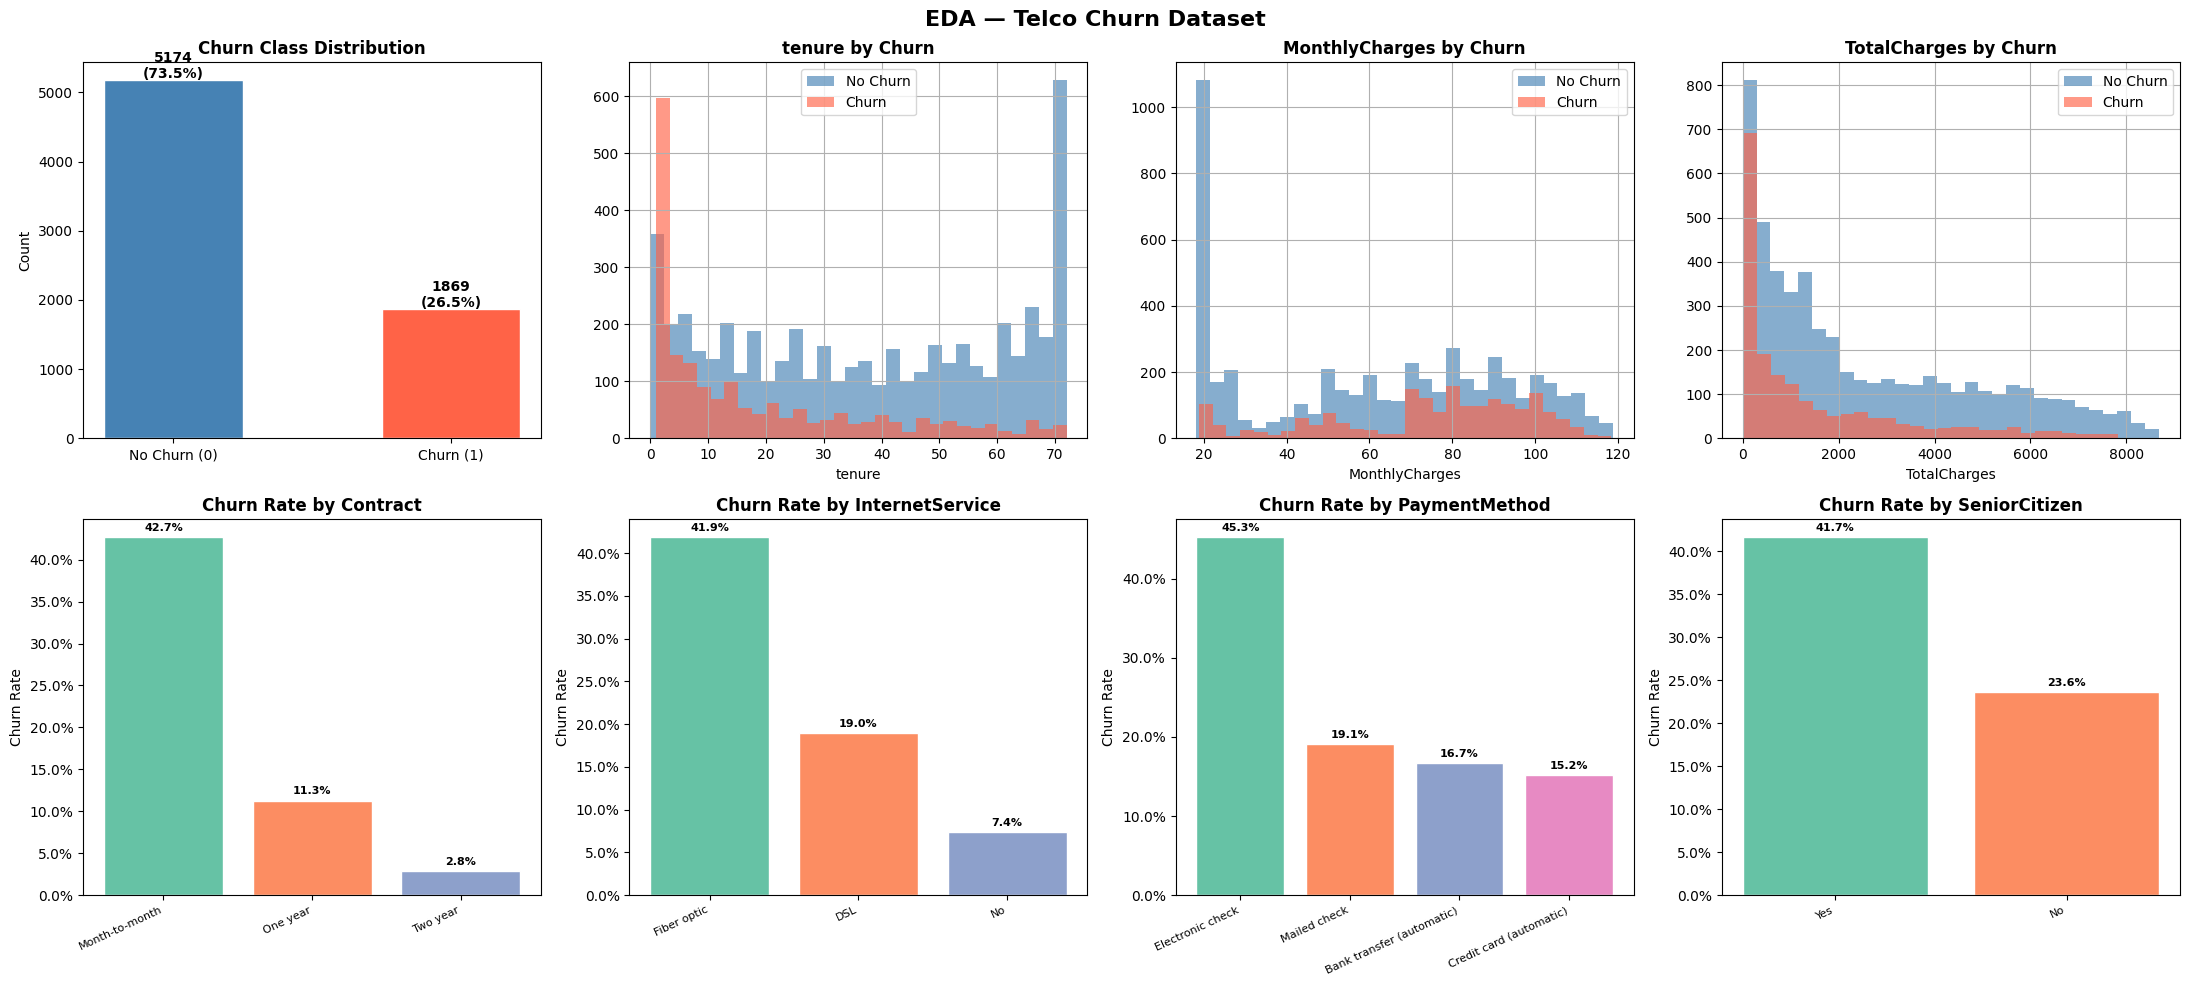

EDA plot saved -> eda_plots.png


In [ ]:
# Churn Distribution + Numeric Feature Distributions
fig, axes = plt.subplots(2, 4, figsize=(22, 10))  # Create 2x4 grid of subplots
fig.suptitle('EDA — Telco Churn Dataset', fontsize=16, fontweight='bold')  # Main title

# ── Row 1: Churn bar + numeric histograms ────────────────────────────────────
# Churn class distribution
churn_counts = df[TARGET_COL].value_counts()  # Count churned vs non-churned
axes[0, 0].bar(
    ['No Churn (0)', 'Churn (1)'],
    churn_counts.values,
    color=['steelblue', 'tomato'],
    edgecolor='white', width=0.5,
)
for i, v in enumerate(churn_counts.values):  # Add labels above bars
    axes[0, 0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontweight='bold')
axes[0, 0].set_title('Churn Class Distribution', fontweight='bold')  # Subplot title
axes[0, 0].set_ylabel('Count')  # Y-axis label

# Numeric feature distributions by churn
for col, ax in zip(NUMERIC_FEATURES, axes[0, 1:]):  # Loop through numeric features
    df[df[TARGET_COL] == 0][col].hist(  # Histogram for non-churn
        ax=ax, bins=30, alpha=0.65, label='No Churn', color='steelblue'
    )
    df[df[TARGET_COL] == 1][col].hist(  # Histogram for churn
        ax=ax, bins=30, alpha=0.65, label='Churn', color='tomato'
    )
    ax.set_title(col + ' by Churn', fontweight='bold')  # Dynamic title
    ax.set_xlabel(col)  # X-axis label
    ax.legend()  # Show legend

# ── Row 2: Categorical churn rates ───────────────────────────────────────────
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']  # Key categorical features
for col, ax in zip(cat_cols, axes[1]):  # Loop through categorical columns
    churn_rate = df.groupby(col)[TARGET_COL].mean().sort_values(ascending=False)  # Calculate churn rate per category
    bars = ax.bar(
        range(len(churn_rate)),
        churn_rate.values,
        color=sns.color_palette('Set2', len(churn_rate)),
        edgecolor='white',
    )
    ax.set_xticks(range(len(churn_rate)))  # Set tick positions
    ax.set_xticklabels(churn_rate.index, rotation=25, ha='right', fontsize=8)  # Category labels
    ax.set_title('Churn Rate by ' + col, fontweight='bold')  # Dynamic title
    ax.set_ylabel('Churn Rate')  # Y-axis label
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))  # Format as percentage
    for bar, val in zip(bars, churn_rate.values):  # Add value labels on bars
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')  # Save high-res image
plt.show()  # Display plots
print('EDA plot saved -> eda_plots.png')  # Confirmation message

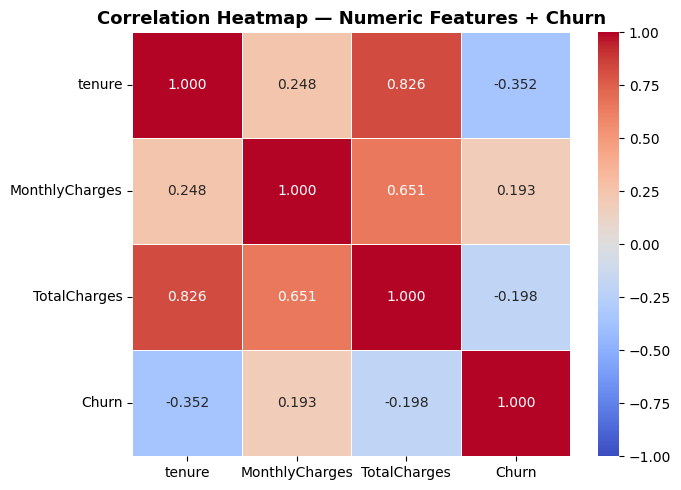

Heatmap saved -> correlation_heatmap.png

Churn correlation (sorted):
MonthlyCharges    0.193
TotalCharges     -0.198
tenure           -0.352


In [ ]:
# Correlation Heatmap (Numeric Features + Target)
fig, ax = plt.subplots(figsize=(7, 5))  # Create figure with 7x5 inch size

corr_df = df[NUMERIC_FEATURES + [TARGET_COL]].corr()  # Compute correlation matrix for numeric features + target
mask    = np.triu(np.ones_like(corr_df, dtype=bool))  # Create mask to hide upper triangle (reduces redundancy)

sns.heatmap(
    corr_df,
    annot=True,  # Show correlation values inside cells
    fmt='.3f',  # Format values to 3 decimal places
    cmap='coolwarm',  # Color scheme: red=positive, blue=negative
    center=0,  # Center colormap at 0
    linewidths=0.5,  # Thin lines between cells
    ax=ax,  # Plot on the created axes
    vmin=-1, vmax=1,  # Fixed color scale range
)
ax.set_title('Correlation Heatmap — Numeric Features + Churn', fontweight='bold', fontsize=13)  # Title with bold
plt.tight_layout()  # Adjust layout to avoid clipping
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')  # Save as high-res PNG
plt.show()  # Display the heatmap
print('Heatmap saved -> correlation_heatmap.png')  # Confirmation message

print('\nChurn correlation (sorted):')  # Header for sorted correlations
print(corr_df[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False).round(3).to_string())  # Show correlation with target, descending order

In [ ]:
# Stratified Train / Test Split
X = df.drop(columns=[TARGET_COL])  # Features: all columns except target
y = df[TARGET_COL]  # Target: churn column (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,  # 80% train, 20% test
    random_state = RANDOM_SEED,  # Fixed seed for reproducibility
    stratify     = y,   # Preserves churn ratio in both sets (handles imbalance)
)

log.info('Train : %d rows | churn %.1f%%', len(X_train), y_train.mean()*100)  # Log train set info
log.info('Test  : %d rows | churn %.1f%%', len(X_test),  y_test.mean()*100)  # Log test set info

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')  # Show feature matrix shapes
print(f'y_train churn rate : {y_train.mean()*100:.1f}%')  # Verify stratification preserved churn %
print(f'y_test  churn rate : {y_test.mean()*100:.1f}%')  # Test set should have similar churn %

2026-05-25 10:16:05,527 [INFO] Train : 5634 rows | churn 26.5%
2026-05-25 10:16:05,530 [INFO] Test  : 1409 rows | churn 26.5%
X_train : (5634, 19)   X_test : (1409, 19)
y_train churn rate : 26.5%
y_test  churn rate : 26.5%


In [ ]:
# ColumnTransformer Preprocessor
def make_preprocessor():
    """
    Build a fresh ColumnTransformer.
    Always call once per pipeline — never share the same instance between pipelines.
    """
    numeric_branch = Pipeline(  # Pipeline for numeric features
        steps=[('scaler', StandardScaler())]  # Standardize to mean=0, std=1
    )
    categorical_branch = Pipeline(  # Pipeline for categorical features
        steps=[('ohe', OneHotEncoder(  # Convert categories to binary columns
            handle_unknown='ignore',  # Ignore unseen categories in test data
            sparse_output=False,  # Return dense array instead of sparse matrix
        ))]
    )
    return ColumnTransformer(  # Apply different preprocessing to different columns
        transformers=[
            ('numeric',     numeric_branch,     NUMERIC_FEATURES),  # Scale numeric
            ('categorical', categorical_branch, CATEGORICAL_FEATURES),  # Encode categorical
        ],
        remainder='drop',  # Drop any columns not specified
        verbose_feature_names_out=True,  # Prefix feature names with transformer name
    )


# ── Sanity-check output shape ─────────────────────────────────────────────────
_prep    = make_preprocessor()  # Create preprocessor instance
_out     = _prep.fit_transform(X_train)  # Fit on train and transform
_names   = _prep.get_feature_names_out()  # Get transformed feature names
n_ohe    = _out.shape[1] - len(NUMERIC_FEATURES)  # Calculate number of OHE columns

print(f'Preprocessor output shape : {_out.shape}')  # Show transformed matrix dimensions
print(f'  {len(NUMERIC_FEATURES)} scaled numeric cols')  # Confirm numeric count
print(f'  {n_ohe} one-hot encoded cols')  # Show OHE columns count
print(f'  {len(_names)} total feature names')  # Total features after transformation
print('\nFirst 8 feature names after transformation:')
for i, n in enumerate(_names[:8]):  # Preview first 8 transformed feature names
    print(f'  [{i}] {n}')
print(f'  ... ({len(_names)} total)')  # Indicate remaining features

Preprocessor output shape : (5634, 46)
  3 scaled numeric cols
  43 one-hot encoded cols
  46 total feature names

First 8 feature names after transformation:
  [0] numeric__tenure
  [1] numeric__MonthlyCharges
  [2] numeric__TotalCharges
  [3] categorical__gender_Female
  [4] categorical__gender_Male
  [5] categorical__SeniorCitizen_No
  [6] categorical__SeniorCitizen_Yes
  [7] categorical__Partner_No
  ... (46 total)


In [ ]:
# Model Pipelines
def build_lr_pipeline(preprocessor):
    """Logistic Regression pipeline with balanced class weights."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),  # Apply scaling + encoding
        ('classifier', LogisticRegression(
            solver       = 'lbfgs',  # Optimization algorithm for small datasets
            max_iter     = 1000,     # Sufficient iterations for convergence
            random_state = RANDOM_SEED,  # Reproducibility
            class_weight = 'balanced',  # Penalize minority class errors more (handles imbalance)
        )),
    ])


def build_rf_pipeline(preprocessor):
    """Random Forest pipeline with balanced class weights."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),  # Apply scaling + encoding
        ('classifier', RandomForestClassifier(
            random_state = RANDOM_SEED,  # Reproducibility
            class_weight = 'balanced',  # Handles class imbalance automatically
            n_jobs       = -1,          # Use all CPU cores for faster training
        )),
    ])


# Each pipeline MUST have its own preprocessor instance (no sharing)
lr_pipeline = build_lr_pipeline(make_preprocessor())  # Fresh preprocessor for LR
rf_pipeline = build_rf_pipeline(make_preprocessor())  # Fresh preprocessor for RF

print('LR pipeline steps :', [s[0] for s in lr_pipeline.steps])  # Show step names
print('RF pipeline steps :', [s[0] for s in rf_pipeline.steps])  # Show step names
print('\nLR classifier      :', lr_pipeline.named_steps['classifier'])  # Show LR params
print('\nRF classifier      :', rf_pipeline.named_steps['classifier'])  # Show RF params

LR pipeline steps : ['preprocessor', 'classifier']
RF pipeline steps : ['preprocessor', 'classifier']

LR classifier      : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

RF classifier      : RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


In [ ]:
# GridSearchCV: Logistic Regression
log.info('[GridSearchCV] Tuning Logistic Regression ...')  # Log start of hyperparameter tuning

param_grid_lr = {
    'classifier__C':       [0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization strength (lower = stronger)
    'classifier__penalty': ['l2'],  # L2 regularization (Ridge)
}

gs_lr = GridSearchCV(
    estimator  = lr_pipeline,  # Pipeline with preprocessor + LR
    param_grid = param_grid_lr,  # Hyperparameter grid
    cv         = 5,           # 5-fold stratified cross-validation
    scoring    = 'roc_auc',   # Primary evaluation metric (area under ROC curve)
    n_jobs     = -1,          # Use all CPU cores for parallel processing
    verbose    = 1,           # Print progress during fitting
    refit      = True,        # Refit best model on full training set
    return_train_score = True,  # Include training scores in results
)
gs_lr.fit(X_train, y_train)  # Execute grid search

log.info('LR best_params : %s', gs_lr.best_params_)  # Log best hyperparameters found
log.info('LR best CV AUC : %.4f', gs_lr.best_score_)  # Log best cross-validation score

# Full CV results as DataFrame
cv_lr = pd.DataFrame(gs_lr.cv_results_)[[  # Extract relevant columns
    'param_classifier__C',
    'mean_train_score',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].copy()
cv_lr.columns = ['C', 'Train AUC', 'CV AUC', 'Std', 'Rank']  # Rename for clarity
cv_lr = cv_lr.sort_values('Rank').round(4)  # Sort by rank, round to 4 decimals
print('\nLogistic Regression — GridSearch CV Results:')
print(cv_lr.to_string(index=False))  # Display results without index

2026-05-25 10:19:58,210 [INFO] [GridSearchCV] Tuning Logistic Regression ...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
2026-05-25 10:20:00,681 [INFO] LR best_params : {'classifier__C': 100.0, 'classifier__penalty': 'l2'}
2026-05-25 10:20:00,683 [INFO] LR best CV AUC : 0.8456

Logistic Regression — GridSearch CV Results:
     C  Train AUC  CV AUC    Std  Rank
100.00     0.8498  0.8456 0.0140     1
 10.00     0.8497  0.8455 0.0141     2
  1.00     0.8495  0.8454 0.0141     3
  0.10     0.8487  0.8449 0.0142     4
  0.01     0.8463  0.8433 0.0145     5


In [ ]:
# GridSearchCV: Random Forest
log.info('[GridSearchCV] Tuning Random Forest ...')  # Log start of RF hyperparameter tuning

param_grid_rf = {
    'classifier__n_estimators':      [100, 200, 300],  # Number of trees in forest
    'classifier__max_depth':         [None, 5, 10, 20],  # Max depth (None = unlimited)
    'classifier__min_samples_split': [2, 5],  # Minimum samples required to split node
}

gs_rf = GridSearchCV(
    estimator  = rf_pipeline,  # Pipeline with preprocessor + RF
    param_grid = param_grid_rf,  # Hyperparameter grid
    cv         = 5,  # 5-fold stratified cross-validation
    scoring    = 'roc_auc',  # Primary evaluation metric
    n_jobs     = -1,  # Use all CPU cores
    verbose    = 1,  # Print progress
    refit      = True,  # Refit best model on full training set
    return_train_score = True,  # Include training scores
)
gs_rf.fit(X_train, y_train)  # Execute grid search

log.info('RF best_params : %s', gs_rf.best_params_)  # Log best hyperparameters
log.info('RF best CV AUC : %.4f', gs_rf.best_score_)  # Log best CV score

# Top 5 configurations
cv_rf = pd.DataFrame(gs_rf.cv_results_)[[  # Extract relevant columns
    'param_classifier__n_estimators',
    'param_classifier__max_depth',
    'param_classifier__min_samples_split',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].copy()
cv_rf.columns = ['n_est', 'max_depth', 'min_split', 'CV AUC', 'Std', 'Rank']  # Rename for clarity
cv_rf = cv_rf.sort_values('Rank').round(4)  # Sort by rank
print('\nRandom Forest — Top 5 Configurations:')
print(cv_rf.head(5).to_string(index=False))  # Show only top 5 results

2026-05-25 10:21:11,449 [INFO] [GridSearchCV] Tuning Random Forest ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
2026-05-25 10:23:47,623 [INFO] RF best_params : {'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
2026-05-25 10:23:47,624 [INFO] RF best CV AUC : 0.8445

Random Forest — Top 5 Configurations:
 n_est max_depth  min_split  CV AUC    Std  Rank
   100         5          5  0.8445 0.0145     1
   200        10          5  0.8444 0.0124     2
   300        10          5  0.8444 0.0122     3
   100         5          2  0.8444 0.0144     4
   300         5          5  0.8442 0.0148     5


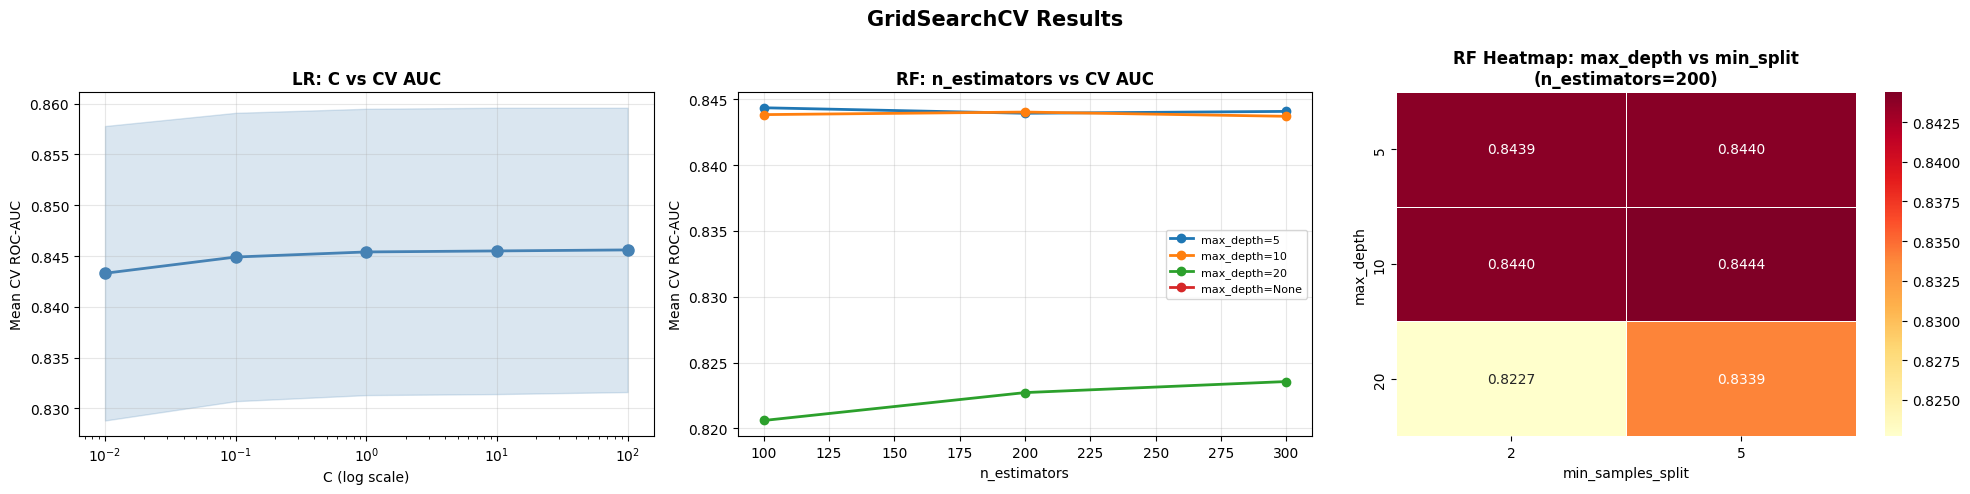

GridSearch visualisation saved -> gridsearch_results.png


In [ ]:
# GridSearch Results Visualisation
fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # Create 1 row, 3 columns of subplots
fig.suptitle('GridSearchCV Results', fontsize=15, fontweight='bold')  # Main title

# ── LR: C vs CV AUC ──────────────────────────────────────────────────────────
axes[0].plot(
    cv_lr['C'].astype(float),  # Regularization parameter C
    cv_lr['CV AUC'],  # Mean cross-validation AUC
    marker='o', linewidth=2, color='steelblue', markersize=8,
)
axes[0].fill_between(
    cv_lr['C'].astype(float),
    cv_lr['CV AUC'] - cv_lr['Std'],  # Lower bound (mean - std)
    cv_lr['CV AUC'] + cv_lr['Std'],  # Upper bound (mean + std)
    alpha=0.2, color='steelblue',  # Shaded confidence interval
)
axes[0].set_xscale('log')  # Log scale for C (since it's multiplicative)
axes[0].set_title('LR: C vs CV AUC', fontweight='bold')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('Mean CV ROC-AUC')
axes[0].grid(True, alpha=0.3)  # Light grid lines

# ── RF: n_estimators vs CV AUC (per max_depth) ───────────────────────────────
rf_cv_df = pd.DataFrame(gs_rf.cv_results_)  # Convert RF grid search results to DataFrame
for depth in [5, 10, 20, None]:  # Loop through max_depth values
    subset = rf_cv_df[
        (rf_cv_df['param_classifier__max_depth'] == depth) &
        (rf_cv_df['param_classifier__min_samples_split'] == 2)  # Fix min_split=2
    ].sort_values('param_classifier__n_estimators')
    label = f'max_depth={depth}'
    axes[1].plot(
        subset['param_classifier__n_estimators'].astype(int),  # Number of trees
        subset['mean_test_score'],  # CV AUC
        marker='o', label=label, linewidth=2,
    )
axes[1].set_title('RF: n_estimators vs CV AUC', fontweight='bold')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('Mean CV ROC-AUC')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# ── RF: max_depth heatmap (n_est=200) ────────────────────────────────────────
pivot = rf_cv_df[
    rf_cv_df['param_classifier__n_estimators'] == 200  # Fix trees at 200
].pivot_table(
    index='param_classifier__max_depth',  # Rows = max_depth
    columns='param_classifier__min_samples_split',  # Columns = min_samples_split
    values='mean_test_score',  # Values = CV AUC
)
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',  # Yellow-Orange-Red colormap
    ax=axes[2], linewidths=0.5,
)
axes[2].set_title('RF Heatmap: max_depth vs min_split\n(n_estimators=200)', fontweight='bold')
axes[2].set_xlabel('min_samples_split')
axes[2].set_ylabel('max_depth')

plt.tight_layout()  # Adjust spacing
plt.savefig('gridsearch_results.png', dpi=150, bbox_inches='tight')  # Save high-res
plt.show()  # Display plots
print('GridSearch visualisation saved -> gridsearch_results.png')  # Confirmation

In [ ]:
# Model Evaluation
def evaluate_model(name, gs):
    """
    Evaluate a fitted GridSearchCV on the test set.
    Prints all metrics and a full classification report.
    Returns a metrics dict.
    """
    best   = gs.best_estimator_  # Extract best model from grid search
    y_pred = best.predict(X_test)  # Predict class labels
    y_prob = best.predict_proba(X_test)[:, 1]  # Predict probabilities (for ROC-AUC)

    m = dict(
        model     = name,
        accuracy  = accuracy_score (y_test, y_pred),  # Overall correct predictions
        precision = precision_score(y_test, y_pred),  # Precision = TP/(TP+FP)
        recall    = recall_score   (y_test, y_pred),  # Recall = TP/(TP+FN)
        f1        = f1_score       (y_test, y_pred),  # Harmonic mean of precision & recall
        roc_auc   = roc_auc_score  (y_test, y_prob),  # Area under ROC curve
        cv_auc    = gs.best_score_,  # Best cross-validation AUC from grid search
    )

    print('\n' + '='*58)
    print(f'  {name} — Test-set Results')
    print('='*58)
    print(f'  Accuracy  : {m["accuracy"]:.4f}')  # Print accuracy
    print(f'  Precision : {m["precision"]:.4f}')  # Print precision
    print(f'  Recall    : {m["recall"]:.4f}')  # Print recall
    print(f'  F1 Score  : {m["f1"]:.4f}')  # Print F1
    print(f'  ROC-AUC   : {m["roc_auc"]:.4f}  <- test set')  # Test ROC-AUC
    print(f'  CV AUC    : {m["cv_auc"]:.4f}  <- best GridSearch fold')  # Cross-val AUC
    print('='*58)
    print(classification_report(  # Full breakdown per class
        y_test, y_pred,
        target_names=['No Churn', 'Churn'],  # Class labels
    ))
    return m


m_lr = evaluate_model('Logistic Regression', gs_lr)  # Evaluate LR
m_rf = evaluate_model('Random Forest',       gs_rf)  # Evaluate RF


  Logistic Regression — Test-set Results
  Accuracy  : 0.7381
  Precision : 0.5043
  Recall    : 0.7807
  F1 Score  : 0.6128
  ROC-AUC   : 0.8403  <- test set
  CV AUC    : 0.8456  <- best GridSearch fold
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Random Forest — Test-set Results
  Accuracy  : 0.7438
  Precision : 0.5113
  Recall    : 0.7834
  F1 Score  : 0.6188
  ROC-AUC   : 0.8394  <- test set
  CV AUC    : 0.8445  <- best GridSearch fold
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      

In [ ]:
# Side-by-Side Model Comparison
comparison = pd.DataFrame([m_lr, m_rf]).set_index('model') # Create comparison DataFrame with models as rows
comparison.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'Test AUC', 'CV AUC'] # Rename columns
comparison = comparison.round(4) # Round to 4 decimals for readability
print(comparison.to_string()) # Display comparison table
print('\nBest Test AUC model:', comparison['Test AUC'].idxmax()) # Identify best model by test AUC
# Display styled comparison (remove the backslash line continuation issue)
comparison.style\
    .highlight_max(axis=0, color='#c6efce').highlight_min(axis=0, color='#ffc7ce').format('{:.4f}')


                     Accuracy  Precision  Recall      F1  Test AUC  CV AUC
model                                                                     
Logistic Regression    0.7381     0.5043  0.7807  0.6128    0.8403  0.8456
Random Forest          0.7438     0.5113  0.7834  0.6188    0.8394  0.8445

Best Test AUC model: Logistic Regression


,Accuracy,Precision,Recall,F1,Test AUC,CV AUC
model,,,,,,
Logistic Regression,0.7381,0.5043,0.7807,0.6128,0.8403,0.8456
Random Forest,0.7438,0.5113,0.7834,0.6188,0.8394,0.8445


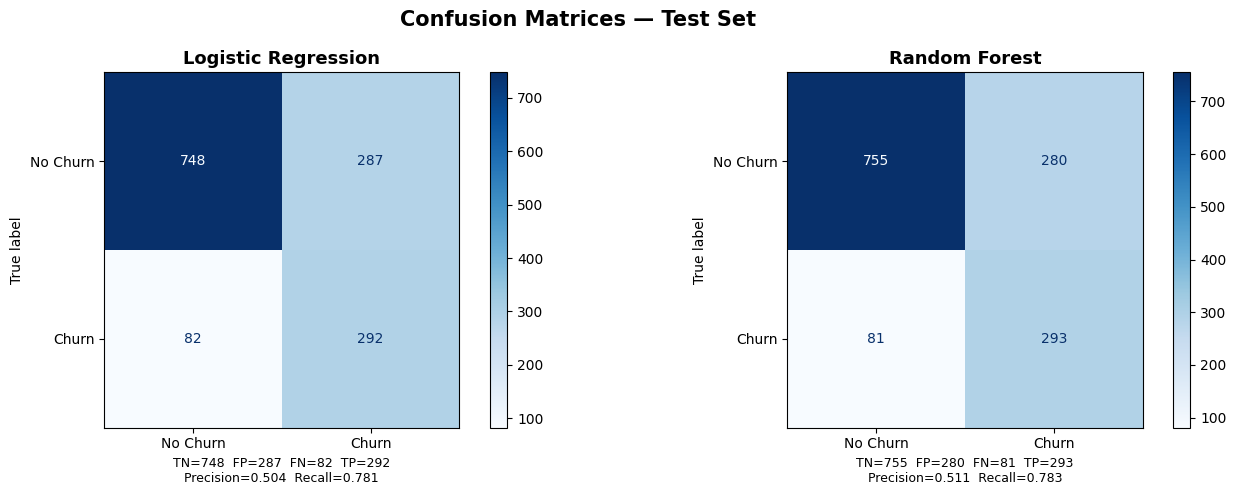

Confusion matrix plot saved -> confusion_matrices.png


In [ ]:
# Confusion Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Create 1 row, 2 columns of subplots
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')  # Main title

for ax, (name, gs) in zip(
    axes,
    [('Logistic Regression', gs_lr), ('Random Forest', gs_rf)],  # Iterate through both models
):
    y_pred = gs.best_estimator_.predict(X_test)  # Get predictions from best model
    cm     = confusion_matrix(y_test, y_pred)  # Compute confusion matrix
    disp   = ConfusionMatrixDisplay(
        confusion_matrix = cm,
        display_labels   = ['No Churn', 'Churn'],  # Label classes
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues')  # Plot with blue colormap
    ax.set_title(name, fontweight='bold', fontsize=13)  # Model name as subtitle

    # Annotate with raw counts and derived metrics
    tn, fp, fn, tp = cm.ravel()  # Extract confusion matrix components
    total = cm.sum()  # Total predictions (not used but available)
    ax.set_xlabel(
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'  # Show raw counts
        f'Precision={tp/(tp+fp):.3f}  Recall={tp/(tp+fn):.3f}',  # Show derived metrics
        fontsize=9,
    )

plt.tight_layout()  # Adjust spacing to prevent overlap
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')  # Save high-res image
plt.show()  # Display the plots
print('Confusion matrix plot saved -> confusion_matrices.png')  # Confirmation message

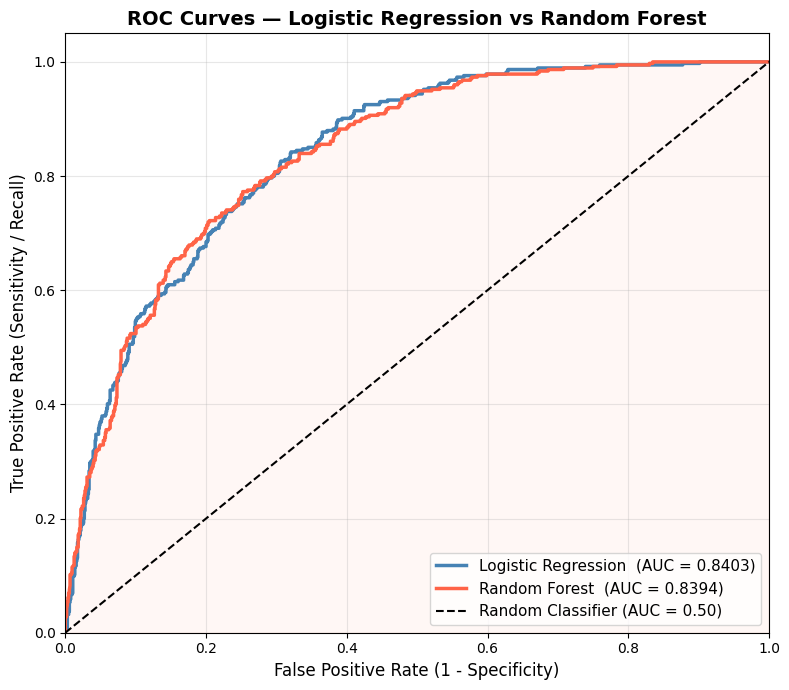

ROC curve saved -> roc_curves.png
LR  AUC : 0.8403
RF  AUC : 0.8394


In [ ]:
# ROC Curve Plot
fig, ax = plt.subplots(figsize=(8, 7))  # Create figure for ROC curves

colors = {'Logistic Regression': 'steelblue', 'Random Forest': 'tomato'}  # Assign colors per model

for name, gs in [
    ('Logistic Regression', gs_lr),
    ('Random Forest',       gs_rf),
]:
    y_prob = gs.best_estimator_.predict_proba(X_test)[:, 1]  # Get predicted probabilities for positive class
    fpr, tpr, _ = roc_curve(y_test, y_prob)  # Compute false positive rate and true positive rate
    roc_auc_val = auc(fpr, tpr)  # Calculate area under the curve
    ax.plot(
        fpr, tpr,
        label=f'{name}  (AUC = {roc_auc_val:.4f})',  # Label with AUC value
        color=colors[name],
        linewidth=2.5,
    )

# Random classifier baseline (no skill)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.50)')  # Diagonal line

ax.set_xlim([0.0, 1.0])  # X-axis limits (FPR)
ax.set_ylim([0.0, 1.05])  # Y-axis limits (TPR)
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)  # X-axis label
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)  # Y-axis label
ax.set_title('ROC Curves — Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')  # Title
ax.legend(loc='lower right', fontsize=11)  # Legend position
ax.grid(True, alpha=0.3)  # Light grid for readability
ax.fill_between(fpr, tpr, alpha=0.05, color='tomato')  # Fill under curve (for RF, last loop)

plt.tight_layout()  # Adjust layout
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')  # Save figure
plt.show()  # Display
print('ROC curve saved -> roc_curves.png')  # Confirmation
print(f'LR  AUC : {roc_auc_score(y_test, gs_lr.best_estimator_.predict_proba(X_test)[:,1]):.4f}')  # Print LR test AUC
print(f'RF  AUC : {roc_auc_score(y_test, gs_rf.best_estimator_.predict_proba(X_test)[:,1]):.4f}')  # Print RF test AUC

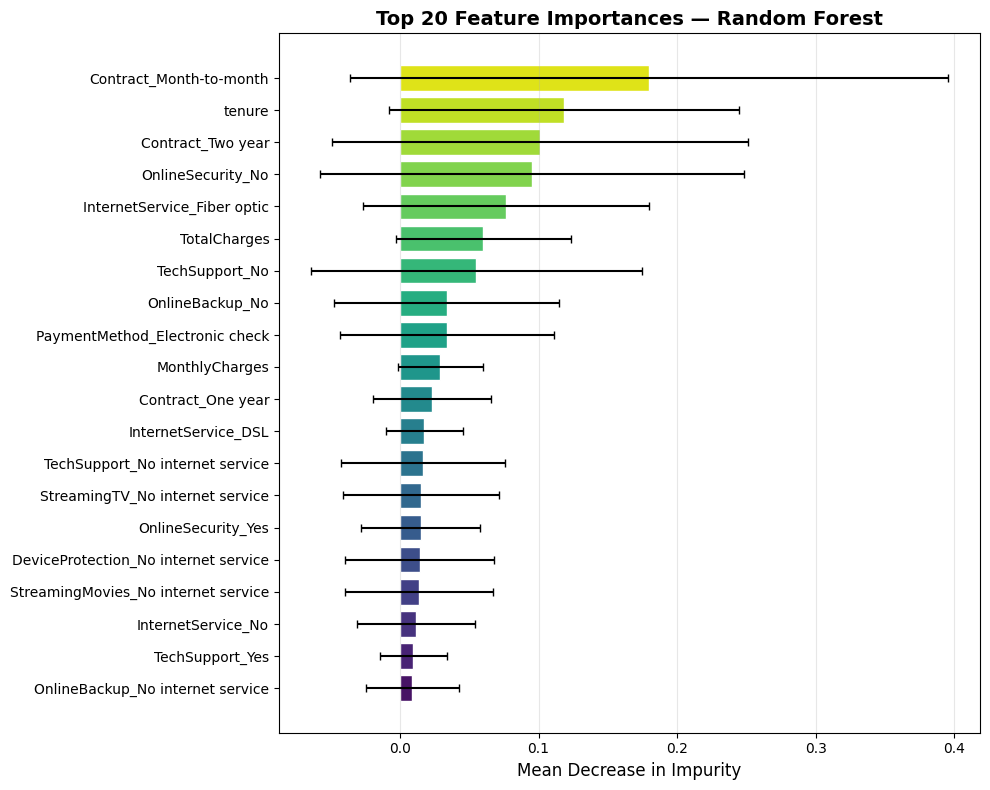

Feature importance plot saved -> feature_importance.png

Top 15 Features:
                        Feature  Importance     Std
        Contract_Month-to-month     0.17974 0.21572
                         tenure     0.11819 0.12642
              Contract_Two year     0.10087 0.15023
              OnlineSecurity_No     0.09516 0.15315
    InternetService_Fiber optic     0.07647 0.10340
                   TotalCharges     0.06014 0.06308
                 TechSupport_No     0.05518 0.11945
                OnlineBackup_No     0.03386 0.08107
 PaymentMethod_Electronic check     0.03382 0.07718
                 MonthlyCharges     0.02895 0.03062
              Contract_One year     0.02317 0.04236
            InternetService_DSL     0.01771 0.02784
TechSupport_No internet service     0.01663 0.05921
StreamingTV_No internet service     0.01538 0.05620
             OnlineSecurity_Yes     0.01484 0.04278


In [ ]:
# Feature Importance (Random Forest)
best_rf = gs_rf.best_estimator_  # Extract best Random Forest model from grid search
feat_names = best_rf.named_steps['preprocessor'].get_feature_names_out()  # Get transformed feature names
importances = best_rf.named_steps['classifier'].feature_importances_  # Extract importance scores
std_imps = np.std(
    [tree.feature_importances_ for tree in
     best_rf.named_steps['classifier'].estimators_],  # Standard deviation across all trees
    axis=0,
)

feat_df = (
    pd.DataFrame({
        'Feature':    feat_names,
        'Importance': importances,
        'Std':        std_imps,
    })
    .sort_values('Importance', ascending=False)  # Sort by importance (highest first)
    .reset_index(drop=True)  # Reset index after sorting
)
# Clean names: remove transformer prefix for readability
feat_df['Feature'] = (
    feat_df['Feature']
    .str.replace('numeric__', '', regex=False)  # Remove 'numeric__' prefix
    .str.replace('categorical__', '', regex=False)  # Remove 'categorical__' prefix
)

# ── Plot top 20 ───────────────────────────────────────────────────────────────
top20 = feat_df.head(20)  # Select top 20 features

fig, ax = plt.subplots(figsize=(10, 8))  # Create horizontal bar chart
bars = ax.barh(
    top20['Feature'][::-1],  # Reverse for highest at top
    top20['Importance'][::-1],  # Reverse to match
    xerr=top20['Std'][::-1],  # Add error bars (standard deviation)
    color=sns.color_palette('viridis', 20),  # Color gradient
    edgecolor='white',  # White borders between bars
    capsize=3,  # Caps on error bars
)
ax.set_title('Top 20 Feature Importances — Random Forest', fontweight='bold', fontsize=14)  # Title
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12)  # X-axis label (importance metric)
ax.set_ylabel('')  # No y-axis label (features are self-explanatory)
ax.grid(True, axis='x', alpha=0.3)  # Light grid lines on x-axis
plt.tight_layout()  # Adjust spacing
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')  # Save plot
plt.show()  # Display
print('Feature importance plot saved -> feature_importance.png')  # Confirmation

# ── Full table ────────────────────────────────────────────────────────────────
print('\nTop 15 Features:')  # Header for top features table
print(feat_df[['Feature','Importance','Std']].head(15).round(5).to_string(index=False))  # Show top 15 with 5 decimals

In [ ]:
# Save Best Pipeline
# ── Select winner by Test AUC ─────────────────────────────────────────────────
if m_rf['roc_auc'] >= m_lr['roc_auc']:  # Compare test AUC between models
    best_model_name = 'Random Forest'  # RF wins
    best_pipeline   = gs_rf.best_estimator_  # Save RF pipeline
    winning_auc     = m_rf['roc_auc']  # Store RF AUC
else:  # LR wins
    best_model_name = 'Logistic Regression'  # LR wins
    best_pipeline   = gs_lr.best_estimator_  # Save LR pipeline
    winning_auc     = m_lr['roc_auc']  # Store LR AUC

log.info('Winner : %s  (Test AUC = %.4f)', best_model_name, winning_auc)  # Log winner

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(best_pipeline, MODEL_PATH, compress=3)  # Save pipeline with compression level 3
size_kb = MODEL_PATH.stat().st_size / 1024  # Calculate file size in KB
log.info('Pipeline saved -> %s  (%.1f KB)', MODEL_PATH, size_kb)  # Log save confirmation

print(f'Winner     : {best_model_name}')  # Display winning model
print(f'Test AUC   : {winning_auc:.4f}')  # Display test AUC score
print(f'Saved to   : {MODEL_PATH}')  # Show save path
print(f'File size  : {size_kb:.1f} KB')  # Show file size
print(f'\nPipeline steps saved:')  # Header for pipeline components
for step_name, step_obj in best_pipeline.steps:  # Iterate through pipeline steps
    print(f'  {step_name}: {type(step_obj).__name__}')  # Display step name and class

2026-05-25 10:41:07,795 [INFO] Winner : Logistic Regression  (Test AUC = 0.8403)
2026-05-25 10:41:07,857 [INFO] Pipeline saved -> best_churn_pipeline.joblib  (2.4 KB)
Winner     : Logistic Regression
Test AUC   : 0.8403
Saved to   : best_churn_pipeline.joblib
File size  : 2.4 KB

Pipeline steps saved:
  preprocessor: ColumnTransformer
  classifier: LogisticRegression


In [ ]:
# Load & Predict Demonstration
# ════════════════════════════════════════════════════════
# COPY THIS BLOCK TO ANY NEW NOTEBOOK / PRODUCTION SCRIPT
# ════════════════════════════════════════════════════════
import joblib
import pandas as pd

# Load the entire pipeline (preprocessor + model)
loaded_pipeline = joblib.load('best_churn_pipeline.joblib')

# Verify on test data
sample_probs = loaded_pipeline.predict_proba(X_test.head(8))[:, 1]
sample_preds = loaded_pipeline.predict(X_test.head(8))
sample_true  = y_test.head(8).values

print('Load & Predict — Round-Trip Verification')
print('='*55)
print(f'{'True Label':<12} {'Predicted':<12} {'Churn Prob':<12} {'Correct?'}')
print('-'*55)
for true, pred, prob in zip(sample_true, sample_preds, sample_probs):
    label_true = 'Churn' if true else 'No Churn'
    label_pred = 'Churn' if pred else 'No Churn'
    correct    = 'YES' if true == pred else 'NO '
    print(f'{label_true:<12} {label_pred:<12} {prob:.4f}       {correct}')

print('='*55)
print(f'Sample accuracy: {(sample_true == sample_preds).mean():.1%}')
log.info('Pipeline loaded and verified successfully.')

Load & Predict — Round-Trip Verification
True Label   Predicted    Churn Prob   Correct?
-------------------------------------------------------
No Churn     No Churn     0.1250       YES
No Churn     Churn        0.8506       NO 
No Churn     No Churn     0.1213       YES
No Churn     Churn        0.6846       NO 
No Churn     No Churn     0.0673       YES
No Churn     Churn        0.8055       NO 
No Churn     Churn        0.7055       NO 
No Churn     No Churn     0.3011       YES
Sample accuracy: 50.0%
2026-05-25 10:43:46,772 [INFO] Pipeline loaded and verified successfully.


In [ ]:
# Single-Customer Prediction
def predict_single_customer(pipeline, customer):
    """
    Predict churn risk for a single customer.

    Parameters
    ----------
    pipeline : fitted sklearn Pipeline (loaded from joblib)
    customer : dict — must contain all NUMERIC + CATEGORICAL feature keys

    Returns
    -------
    dict with:
        churn_probability : float  (0.0 to 1.0)
        churn_prediction  : int    (0 = stay, 1 = churn)
        risk_label        : str    (LOW / MEDIUM / HIGH)

    Raises
    ------
    ValueError — if required feature keys are missing from the dict
    """
    required = set(NUMERIC_FEATURES + CATEGORICAL_FEATURES)  # All features needed
    missing = required - set(customer.keys())  # Find missing keys
    if missing:
        raise ValueError('Customer dict missing required fields: ' + str(missing))

    df_in = pd.DataFrame([customer])  # Convert dict to DataFrame (single row)
    prob = pipeline.predict_proba(df_in)[0, 1]  # Get probability of churn (class 1)
    pred = int(pipeline.predict(df_in)[0])  # Get binary prediction (0/1)

    # Business-defined risk tiers (customizable thresholds)
    if prob >= 0.60:  # High risk: >60% churn probability
        risk = 'HIGH'
    elif prob >= 0.35:  # Medium risk: 35-60%
        risk = 'MEDIUM'
    else:  # Low risk: <35%
        risk = 'LOW'

    return {
        'churn_probability': round(prob, 4),  # Rounded to 4 decimals
        'churn_prediction':  pred,  # 0 or 1
        'risk_label':        risk,  # Categorical risk level
    }


# ── Demo 1: High-risk profile ─────────────────────────────────────────────────
# New customer, Fiber optic, Month-to-month, Electronic check (high churn factors)
high_risk_customer = {
    'gender': 'Female',       'SeniorCitizen': 'No',
    'Partner': 'Yes',         'Dependents': 'No',
    'tenure': 2,              'PhoneService': 'Yes',
    'MultipleLines': 'No',    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',   'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes',     'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes','PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.50,  'TotalCharges': 191.00,
}

# ── Demo 2: Low-risk profile ──────────────────────────────────────────────────
# Loyal customer, DSL, Two-year contract, auto-pay (low churn factors)
low_risk_customer = {
    'gender': 'Male',         'SeniorCitizen': 'No',
    'Partner': 'Yes',         'Dependents': 'Yes',
    'tenure': 60,             'PhoneService': 'Yes',
    'MultipleLines': 'Yes',   'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',  'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes','TechSupport': 'Yes',
    'StreamingTV': 'No',      'StreamingMovies': 'No',
    'Contract': 'Two year',
    'PaperlessBilling': 'No', 'PaymentMethod': 'Bank transfer (automatic)',
    'MonthlyCharges': 55.00,  'TotalCharges': 3300.00,
}

# ── Demo 3: Error handling ────────────────────────────────────────────────────
print('Testing missing-field error handling ...')
try:
    predict_single_customer(loaded_pipeline, {'gender': 'Male'})  # Missing most features
except ValueError as e:
    print(f'  Caught ValueError: {str(e)[:60]} ...')  # Show truncated error

# ── Run both demos ────────────────────────────────────────────────────────────
print()
for label, profile in [
    ('HIGH-RISK Customer (new, Fiber, M-t-M)',        high_risk_customer),
    ('LOW-RISK  Customer (loyal, DSL, Two-year)',  low_risk_customer),
]:
    r = predict_single_customer(loaded_pipeline, profile)  # Call prediction function
    print(f'  -- {label} --')  # Print scenario label
    print(f'     Churn Probability : {r["churn_probability"]:.4f}')  # Show probability
    print(f'     Churn Prediction  : {"Yes" if r["churn_prediction"] else "No"}')  # Convert 0/1 to Yes/No
    print(f'     Risk Label        : {r["risk_label"]}')  # Show risk tier

Testing missing-field error handling ...
  Caught ValueError: Customer dict missing required fields: {'MonthlyCharges', 'S ...

  -- HIGH-RISK Customer (new, Fiber, M-t-M) --
     Churn Probability : 0.8586
     Churn Prediction  : Yes
     Risk Label        : HIGH
  -- LOW-RISK  Customer (loyal, DSL, Two-year) --
     Churn Probability : 0.0501
     Churn Prediction  : No
     Risk Label        : LOW


In [ ]:
# Batch Prediction
def predict_batch(pipeline, df_new):
    """
    Run churn inference on a DataFrame of new customers.

    Parameters
    ----------
    pipeline : fitted sklearn Pipeline
    df_new   : pd.DataFrame with NUMERIC + CATEGORICAL feature columns

    Returns
    -------
    pd.DataFrame — input + churn_probability, churn_prediction, risk_label

    Raises
    ------
    ValueError — if required columns are missing from df_new
    """
    required = set(NUMERIC_FEATURES + CATEGORICAL_FEATURES)  # All required features
    missing = required - set(df_new.columns)  # Check for missing columns
    if missing:
        raise ValueError('Input DataFrame missing columns: ' + str(missing))

    probs = pipeline.predict_proba(df_new)[:, 1]  # Get churn probabilities for all rows
    preds = pipeline.predict(df_new)  # Get binary predictions (0/1)
    risks = [  # Assign risk labels based on probability thresholds
        'HIGH' if p >= 0.60 else 'MEDIUM' if p >= 0.35 else 'LOW'
        for p in probs
    ]

    out = df_new.copy()  # Create output DataFrame (avoid modifying original)
    out['churn_probability'] = probs.round(4)  # Add probability column
    out['churn_prediction']  = preds  # Add prediction column
    out['risk_label']        = risks  # Add risk label column
    return out


# Run on 15 test rows
batch_result = predict_batch(loaded_pipeline, X_test.head(15))  # Predict first 15 test customers

display_cols = [  # Columns to display in results
    'tenure', 'MonthlyCharges', 'Contract',
    'churn_probability', 'churn_prediction', 'risk_label',
]
print('Batch Prediction Results (15 customers):')  # Header
print(batch_result[display_cols].to_string(index=False))  # Show results without index

print('\nRisk tier distribution:')  # Header for risk counts
print(batch_result['risk_label'].value_counts().to_string())  # Count of HIGH/MEDIUM/LOW

print('\nAverage churn probability by risk tier:')  # Header for validation
print(batch_result.groupby('risk_label')['churn_probability']
      .mean().round(4).to_string())  # Verify risk tiers align with probabilities

Batch Prediction Results (15 customers):
 tenure  MonthlyCharges       Contract  churn_probability  churn_prediction risk_label
     72          114.05       Two year             0.1250                 0        LOW
      8          100.15 Month-to-month             0.8506                 1       HIGH
     41           78.35       One year             0.1213                 0        LOW
     18           78.20 Month-to-month             0.6846                 1       HIGH
     72           82.65       Two year             0.0673                 0        LOW
     21           99.85 Month-to-month             0.8055                 1       HIGH
     21           99.15 Month-to-month             0.7055                 1       HIGH
     19           24.10 Month-to-month             0.3011                 0        LOW
     61           19.75       Two year             0.0085                 0        LOW
     17           45.05 Month-to-month             0.6512                 1       HIGH
  